Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [1]:
library(tidymodels)

# Keep the train/test split reproducible
set.seed(730)

── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──



✔ broom        1.0.13     ✔ recipes      1.3.3 
✔ dials        1.4.4      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.6.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 



── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [2]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [3]:
glimpse(diabetes_train)

Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 1, 5, 10, 10, 1, 8, 1, 13, 5, 3, 6, 10, 11…
$ Glucose                  <dbl> 85, 89, 116, 115, 139, 103, 99, 97, 145, 117,…
$ BloodPressure            <dbl> 66, 66, 74, 0, 80, 30, 84, 66, 82, 92, 58, 92…
$ SkinThickness            <dbl> 29, 23, 0, 0, 0, 38, 0, 15, 19, 0, 11, 0, 31,…
$ Insulin                  <dbl> 0, 94, 0, 0, 0, 83, 0, 140, 110, 0, 54, 0, 0,…
$ BMI                      <dbl> 26.6, 28.1, 25.6, 35.3, 27.1, 43.3, 35.4, 23.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.167, 0.201, 0.134, 1.441, 0.183, 0.3…
$ Age                      <dbl> 31, 21, 30, 29, 57, 33, 50, 22, 57, 38, 22, 2…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:** `Outcome` is the suitable response variable because it has two categories: 0 for no diabetes and 1 for diabetes.

Logistic regression is appropriate here because the outcome is binary.

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     | Plasma glucose concentration measured two hours after an oral glucose tolerance test. |
| BMI         | Body mass index, calculated as weight in kilograms divided by height in meters squared. |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

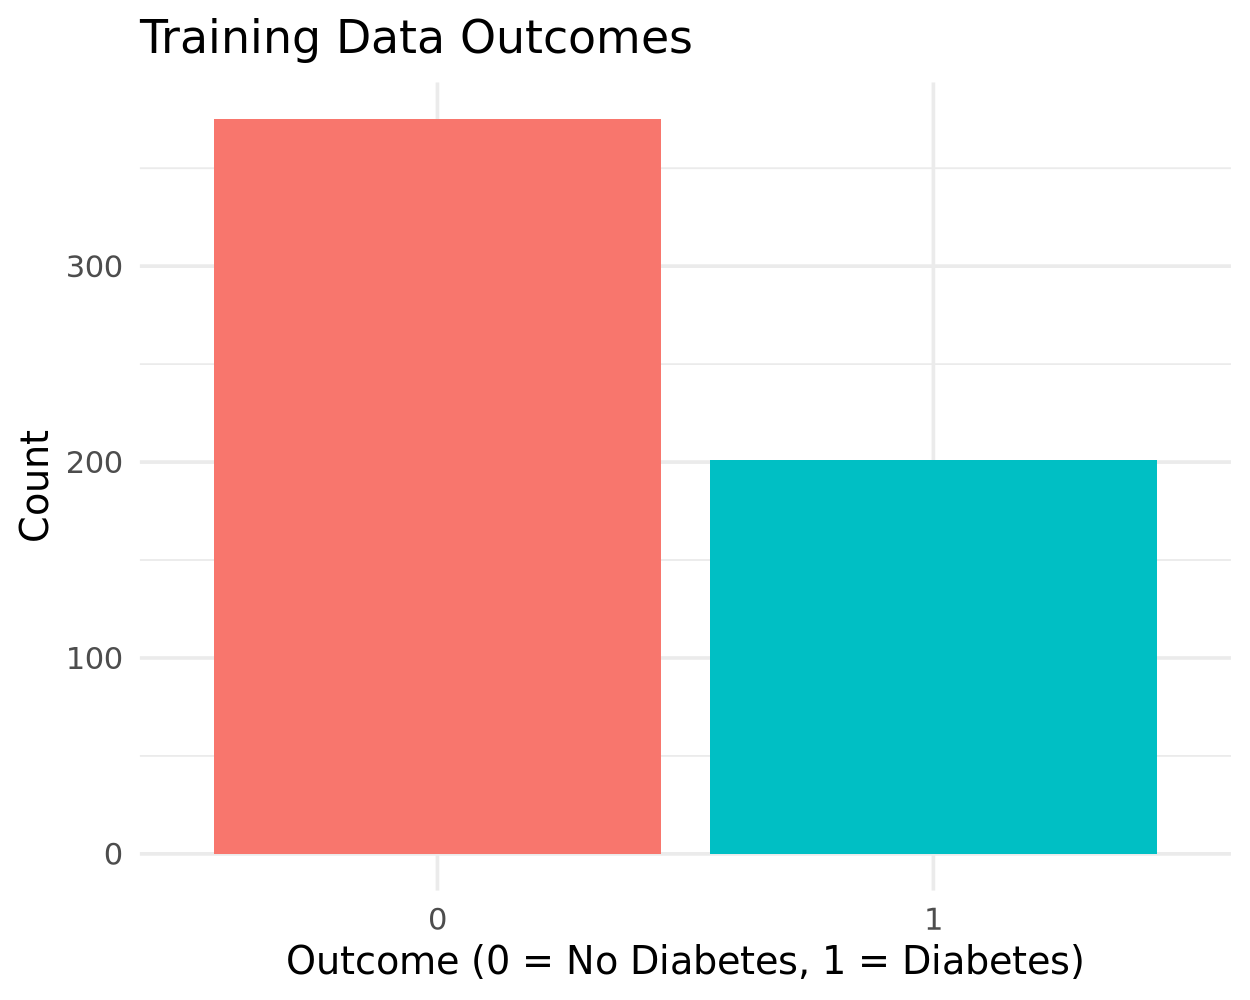

In [4]:
ggplot(diabetes_train, aes(x = Outcome, fill = Outcome)) +
    geom_bar() +
    labs(
        title = "Training Data Outcomes",
        x = "Outcome (0 = No Diabetes, 1 = Diabetes)",
        y = "Count"
    ) +
    theme_minimal() +
    theme(legend.position = "none")

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:** No. The training data has more observations with Outcome 0 than Outcome 1, so the classes are not equally represented.

The bar chart makes the class imbalance easy to see.

Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [5]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,85.0
0,BMI,26.6
0,Glucose,89.0
0,BMI,28.1
0,Glucose,116.0
0,BMI,25.6


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

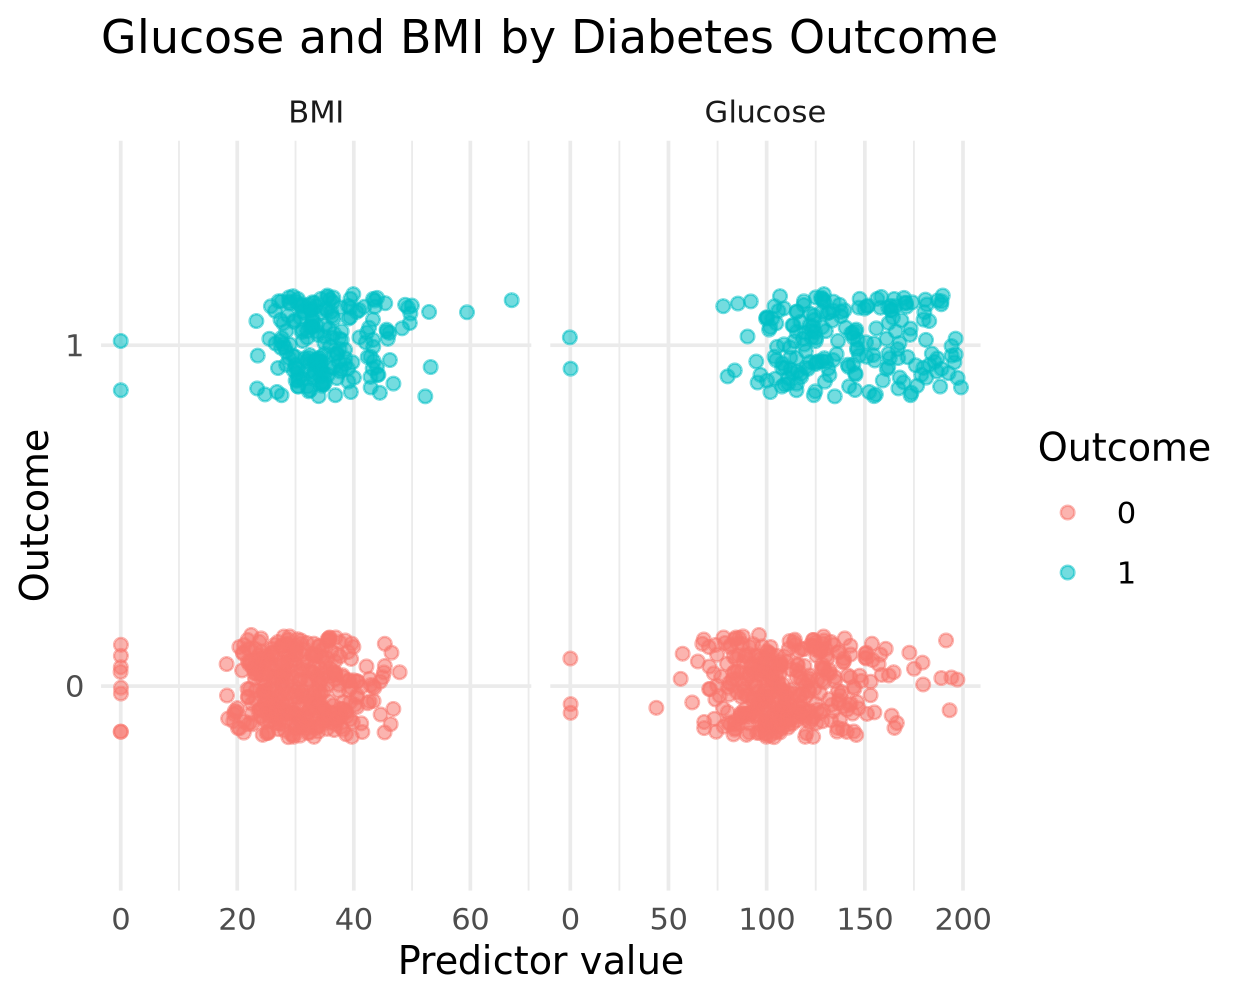

In [6]:
ggplot(plot_df, aes(x = value, y = Outcome, color = Outcome)) +
    geom_jitter(height = 0.15, alpha = 0.55) +
    facet_wrap(~name, ncol = 2, scales = 'free_x') +
    labs(
        title = "Glucose and BMI by Diabetes Outcome",
        x = "Predictor value",
        y = "Outcome"
    ) +
    theme_minimal()

❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:** Both panels use the same x-axis scale. Because Glucose has a much wider range than BMI, the BMI values become compressed and are harder to compare. With `free_x`, each panel uses an x-axis range that fits its variable.

This is why `scales = 'free_x'` is useful when the faceted variables have different units and ranges.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [7]:
mod_spec = logistic_reg() |>
    set_engine("glm")

mod_fit = mod_spec |>
    fit(Outcome ~ BMI + Glucose, data = diabetes_train)

mod_fit

parsnip model object


Call:  stats::glm(formula = Outcome ~ BMI + Glucose, family = stats::binomial, 
    data = data)

Coefficients:
(Intercept)          BMI      Glucose  
   -7.53295      0.08777      0.03257  

Degrees of Freedom: 575 Total (i.e. Null);  573 Residual
Null Deviance:	    745.1 
Residual Deviance: 585.4 	AIC: 591.4

Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [8]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |>
    select(Outcome, .pred_class, .pred_0, .pred_1) |>
    head()

Outcome,.pred_class,.pred_0,.pred_1
<fct>,<fct>,<dbl>,<dbl>
1,1,0.4411042,0.5588958
1,1,0.3291176,0.6708824
0,0,0.6570068,0.3429932
1,1,0.2185226,0.7814774
0,1,0.4949072,0.5050928
0,0,0.6948692,0.3051308


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [9]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 106  28
         1  19  39

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

- There were **67** individuals with diabetes in the test data (28 + 39 in the Truth = 1 column).
- Of those individuals, **39** were correctly predicted to have diabetes.
- The model predicted diabetes for **19** individuals who did not actually have diabetes.